In [1]:
import pandas as pd
import os
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import (recall_score, confusion_matrix, precision_recall_curve, average_precision_score, f1_score)
import time
import matplotlib.pyplot as plt

base_path = os.path.join(os.getcwd(), "..", "data")
processed_path = os.path.join(base_path, "processed")

mali_clean = pd.read_parquet(os.path.join(processed_path, "mali_clean.parquet"))
anom_clean = pd.read_parquet(os.path.join(processed_path, "anom_clean.parquet"))
norm_clean = pd.read_parquet(os.path.join(processed_path, "norm_clean.parquet"))

print(mali_clean.shape, anom_clean.shape, norm_clean.shape)

(19384, 39) (41400, 39) (51208, 39)


In [2]:
# Case-Level Metadaten aus Parquet extrahieren (eine Zeile pro Case)
all_data = pd.concat([mali_clean, anom_clean, norm_clean], ignore_index=True)
case_meta = (all_data
             .drop_duplicates(subset='case_id')[['case_id', 'scenario_id', 'dataset_type', 'label']]
             .reset_index(drop=True))

# Log-Text pro Case laden und aggregieren
def load_log_text(row):
    """Lädt den Syslog-Text einer .log-Datei anhand von dataset_type/scenario_id/case_id.
    Gibt leeren String zurück wenn Datei fehlt (kein Case wird verworfen)."""
    log_filename = row['case_id'].replace('.csv', '.log')
    log_path = os.path.join(base_path, f"{row['dataset_type']}_dataset",
                            row['scenario_id'], log_filename)
    if os.path.exists(log_path):
        with open(log_path, 'r', encoding='utf-8', errors='ignore') as f:
            return f.read()
    return ""

case_meta['log_text'] = case_meta.apply(load_log_text, axis=1)

missing = (case_meta['log_text'] == "").sum()
print(f"Cases gesamt:          {len(case_meta)}")
print(f"Cases mit Log-Text:    {(case_meta['log_text'] != '').sum()}")
print(f"Cases ohne Log-Datei:  {missing}")
print(f"\nLabel-Verteilung (Case-Ebene):\n{case_meta['label'].value_counts()}")

Cases gesamt:          1252
Cases mit Log-Text:    1252
Cases ohne Log-Datei:  0

Label-Verteilung (Case-Ebene):
label
0    1029
1     223
Name: count, dtype: int64


In [3]:
# Gleiche Split-Strategie wie Phase 2 — Vergleichbarkeit sicherstellen
case_meta['group_id'] = case_meta['dataset_type'] + '_' + case_meta['scenario_id'].astype(str)

X_text = case_meta['log_text']
y_case = case_meta['label']
groups = case_meta['group_id']

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X_text, y_case, groups))

X_train_text = X_text.iloc[train_idx].reset_index(drop=True)
X_test_text  = X_text.iloc[test_idx].reset_index(drop=True)
y_train_case = y_case.iloc[train_idx].reset_index(drop=True)
y_test_case  = y_case.iloc[test_idx].reset_index(drop=True)
meta_test_case = case_meta[['dataset_type', 'scenario_id']].iloc[test_idx].reset_index(drop=True)

neg = (y_train_case == 0).sum()
pos = (y_train_case == 1).sum()

print(f"Train: {len(X_train_text)} Cases | Test: {len(X_test_text)} Cases")
print(f"Train pos={pos}, neg={neg} → Ratio: {neg/pos:.2f}")
print(f"Test dataset breakdown:\n{meta_test_case['dataset_type'].value_counts()}")

Train: 999 Cases | Test: 253 Cases
Train pos=175, neg=824 → Ratio: 4.71
Test dataset breakdown:
dataset_type
norm    129
anom     76
mali     48
Name: count, dtype: int64


In [4]:
# TF-IDF: fit nur auf Trainingsdaten (kein Leakage)
vectorizer = TfidfVectorizer(
    max_features=10_000,    # Kompromiss: ausreichend Vokabular, sparse Matrix handhabbar
    ngram_range=(1, 2),     # Bigramme essentiell für Syslog: 'msg audit', 'password for'
    sublinear_tf=True,      # log(tf) statt tf — robuster bei langen Logs mit Wiederholungen
    min_df=2,               # Term muss in ≥2 Cases vorkommen — verhindert Overfitting
    analyzer='word'
)

X_train_tfidf = vectorizer.fit_transform(X_train_text)
X_test_tfidf  = vectorizer.transform(X_test_text)

print(f"Vokabular-Größe:  {len(vectorizer.vocabulary_)}")
print(f"Train Matrix:     {X_train_tfidf.shape}")
print(f"Test Matrix:      {X_test_tfidf.shape}")

Vokabular-Größe:  10000
Train Matrix:     (999, 10000)
Test Matrix:      (253, 10000)


In [5]:
log_reg = LogisticRegression(
    class_weight='balanced',  # Kompensiert 1:4.71-Ungleichgewicht im Trainingsset
    max_iter=1000,            # Erhöht für Konvergenz auf 10k-dimensionaler TF-IDF Matrix
    random_state=42,
    solver='lbfgs',           # Effizient auf sparse hochdimensionalen Matrizen
    C=1.0                     # Standard-Regularisierung; kein Tuning nötig für Baseline
)

log_reg.fit(X_train_tfidf, y_train_case)
print("Training abgeschlossen.")
print(f"Klassen: {log_reg.classes_}")

Training abgeschlossen.
Klassen: [0 1]


In [6]:
t0 = time.time()
y_proba_log = log_reg.predict_proba(X_test_tfidf)[:, 1]
latency_ms = (time.time() - t0) * 1000

precisions, recalls, thresholds = precision_recall_curve(y_test_case, y_proba_log)
ap = average_precision_score(y_test_case, y_proba_log)

# Höchster Threshold wo Recall >= 0.95
valid_thresholds = thresholds[recalls[:-1] >= 0.95]
best_threshold = float(valid_thresholds.max()) if len(valid_thresholds) > 0 else float(thresholds[0])

y_pred_log = (y_proba_log >= best_threshold).astype(int)
tn, fp, fn, tp = confusion_matrix(y_test_case, y_pred_log).ravel()

precision_at_t = tp / (tp + fp) if (tp + fp) > 0 else 0

print(f"Average Precision (AP):  {ap:.4f}")
print(f"Gewählter Threshold:     {best_threshold:.4f}")
print(f"Recall @ threshold:      {recall_score(y_test_case, y_pred_log):.4f}")
print(f"Precision @ threshold:   {precision_at_t:.4f}")
print(f"F1 @ threshold:          {f1_score(y_test_case, y_pred_log):.4f}")
print(f"Latenz predict_proba:    {latency_ms:.1f} ms  ({X_test_tfidf.shape[0]} Cases)")
print(f"FPR gesamt (anom+norm):  {fp / (fp + tn):.4f}  ({fp} FP von {fp+tn})")

Average Precision (AP):  0.7771
Gewählter Threshold:     0.1923
Recall @ threshold:      0.9583
Precision @ threshold:   0.4600
F1 @ threshold:          0.6216
Latenz predict_proba:    2.0 ms  (253 Cases)
FPR gesamt (anom+norm):  0.2634  (54 FP von 205)


In [7]:
# FPR getrennt nach Dataset-Typ: prüft ob Log-Validator zwischen
# technischen Anomalien (anom) und täuschend normalen Szenarien (norm) unterscheidet
for dtype in ['anom', 'norm']:
    mask = (meta_test_case['dataset_type'] == dtype).values
    fp_sub = y_pred_log[mask].sum()
    total_sub = mask.sum()
    print(f"FPR {dtype}: {fp_sub/total_sub:.4f}  ({fp_sub} FP von {total_sub})")

FPR anom: 0.2368  (18 FP von 76)
FPR norm: 0.2791  (36 FP von 129)


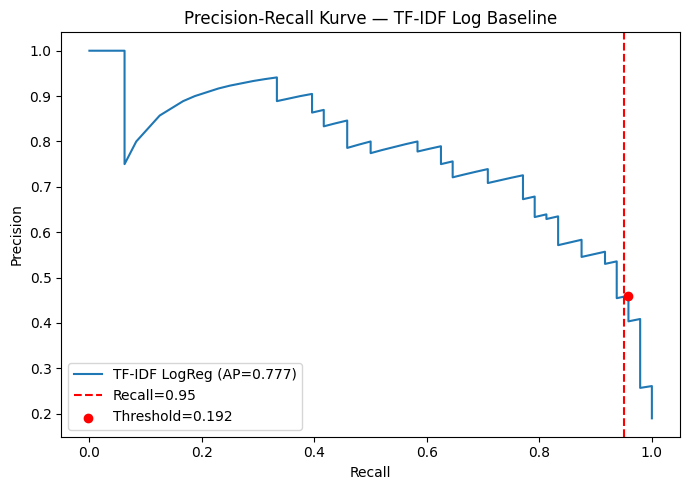

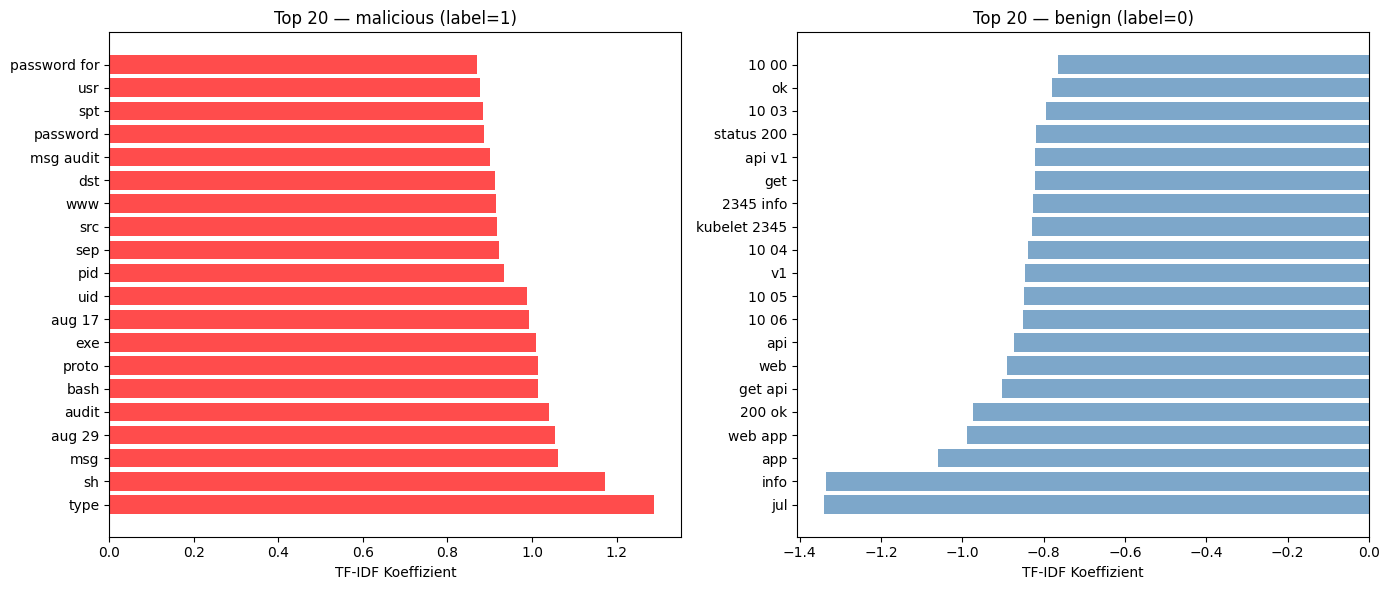

Plots gespeichert.


In [8]:
docs_path = os.path.join(os.getcwd(), "..", "docs")
os.makedirs(docs_path, exist_ok=True)

# PR-Kurve
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(recalls, precisions, label=f'TF-IDF LogReg (AP={ap:.3f})')
ax.axvline(x=0.95, color='red', linestyle='--', label='Recall=0.95')
ax.scatter([recall_score(y_test_case, y_pred_log)],
           [tp / (tp + fp) if (tp + fp) > 0 else 0],
           color='red', zorder=5, label=f'Threshold={best_threshold:.3f}')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Kurve — TF-IDF Log Baseline')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(docs_path, "pr_curve_log.png"), dpi=150)
plt.show()

# Top TF-IDF Features nach Koeffizient
feature_names = vectorizer.get_feature_names_out()
coefs = log_reg.coef_[0]

# Koeffizienten absteigend sortiert: höchste = stärkste malicious-Indikatoren
top_pos_idx = coefs.argsort()[-20:][::-1]
# Aufsteigend sortiert: negativste = stärkste benign-Indikatoren
top_neg_idx = coefs.argsort()[:20]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].barh([feature_names[i] for i in top_pos_idx],
             coefs[top_pos_idx], color='red', alpha=0.7)
axes[0].set_title("Top 20 — malicious (label=1)")
axes[0].set_xlabel("TF-IDF Koeffizient")
axes[1].barh([feature_names[i] for i in top_neg_idx],
             coefs[top_neg_idx], color='steelblue', alpha=0.7)
axes[1].set_title("Top 20 — benign (label=0)")
axes[1].set_xlabel("TF-IDF Koeffizient")
plt.tight_layout()
plt.savefig(os.path.join(docs_path, "tfidf_top_features.png"), dpi=150)
plt.show()
print("Plots gespeichert.")